# 철강 표면 결함 분류 — 전체 최적화 실험과 최종 모델

이 노트북은 Baseline부터 실험 1~11, 최종 실험 12까지의 전체 과정을 하나로 통합한다.

- 데이터 분할은 처음 한 번만 고정한다.
- 각 실험은 고정된 초기 데이터에서 새로운 Dataset과 DataLoader를 생성한다.
- 각 실험마다 Seed, 모델, Optimizer, Scheduler, Early Stopping 상태를 초기화한다.
- Validation 데이터로 모델을 선택하고 Test 데이터는 최종 실험에서만 평가한다.

## 1. 환경 설정

In [1]:
import copy
import gc
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
BATCH_SIZE = 64


def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


reset_seed()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

/Users/bmh7190/skala/skala-ml-dl/day2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


## 2. 초기 데이터 준비 및 분할 고정

In [2]:
path = kagglehub.dataset_download(
    "kaustubhdikshit/neu-surface-defect-database"
)

data_root = Path(path) / "NEU-DET"
train_root = data_root / "train" / "images"
heldout_root = data_root / "validation" / "images"

class_names = sorted(
    folder.name for folder in train_root.iterdir()
    if folder.is_dir()
)

rng = np.random.default_rng(SEED)
train_samples = []
val_samples = []
test_samples = []

for class_id, class_name in enumerate(class_names):
    train_files = sorted((train_root / class_name).glob("*.jpg"))
    heldout_files = sorted((heldout_root / class_name).glob("*.jpg"))
    order = rng.permutation(len(heldout_files))

    val_files = [heldout_files[i] for i in order[:30]]
    test_files = [heldout_files[i] for i in order[30:]]

    train_samples.extend((file, class_id) for file in train_files)
    val_samples.extend((file, class_id) for file in val_files)
    test_samples.extend((file, class_id) for file in test_files)

# 모든 실험이 동일한 초기 분할을 사용하도록 변경 불가능한 기준으로 보관한다.
BASE_TRAIN_SAMPLES = tuple(train_samples)
BASE_VAL_SAMPLES = tuple(val_samples)
BASE_TEST_SAMPLES = tuple(test_samples)

print("data path:", data_root)
print("classes  :", class_names)
print("split    :", len(BASE_TRAIN_SAMPLES), len(BASE_VAL_SAMPLES), len(BASE_TEST_SAMPLES))

data path: /Users/bmh7190/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET
classes  : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
split    : 1440 180 180


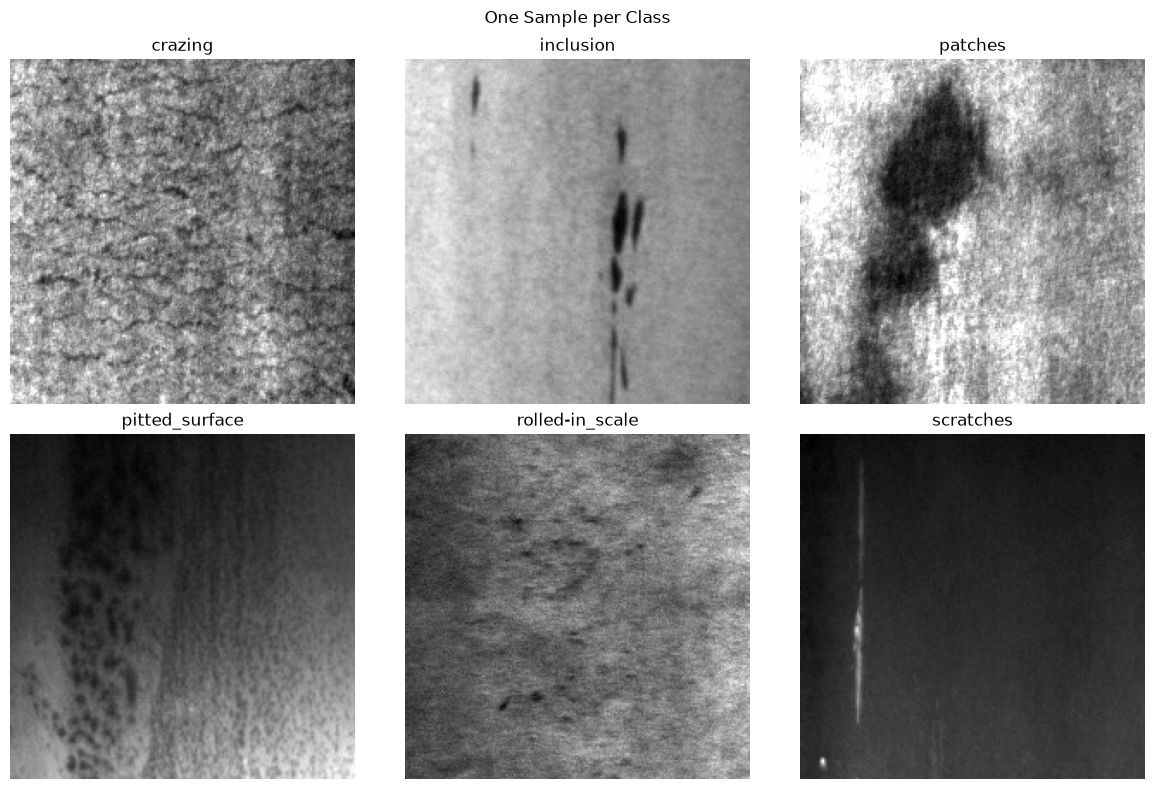

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, class_name in zip(axes.flat, class_names):
    sample_path = sorted((train_root / class_name).glob("*.jpg"))[0]
    ax.imshow(Image.open(sample_path).convert("L"), cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle("One Sample per Class")
plt.tight_layout()
plt.show()

## 3. Dataset, Transform, DataLoader

In [4]:
class SteelDefectDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file, label = self.samples[index]
        image = Image.open(file).convert("L")
        return self.transform(image), label


base_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

flip_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
])

full_augmentation_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(
        degrees=10,
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=128,
    ),
    transforms.ToTensor(),
])


def make_loaders(train_transform, evaluation_transform=base_transform, seed=SEED):
    # 실험마다 기준 데이터에서 새로운 목록과 Dataset을 만든다.
    experiment_train_samples = list(BASE_TRAIN_SAMPLES)
    experiment_val_samples = list(BASE_VAL_SAMPLES)
    experiment_test_samples = list(BASE_TEST_SAMPLES)

    train_dataset = SteelDefectDataset(
        experiment_train_samples, train_transform
    )
    val_dataset = SteelDefectDataset(
        experiment_val_samples, evaluation_transform
    )
    test_dataset = SteelDefectDataset(
        experiment_test_samples, evaluation_transform
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    return train_loader, val_loader, test_loader

## 4. 공통 모델 및 학습 함수

In [5]:
class ExperimentCNN(nn.Module):
    def __init__(
        self,
        channels,
        batch_norm=False,
        feature_dropout=0.0,
        classifier_dropout=0.0,
    ):
        super().__init__()

        feature_layers = []
        in_channels = 1
        spatial_size = 96

        for out_channels in channels:
            feature_layers.append(
                nn.Conv2d(in_channels, out_channels, kernel_size=5)
            )
            if batch_norm:
                feature_layers.append(nn.BatchNorm2d(out_channels))
            feature_layers.append(nn.ReLU())
            feature_layers.append(nn.MaxPool2d(kernel_size=2))

            spatial_size = (spatial_size - 4) // 2
            in_channels = out_channels

        if feature_dropout > 0:
            feature_layers.append(nn.Dropout(feature_dropout))

        classifier_layers = [
            nn.Flatten(),
            nn.Linear(channels[-1] * spatial_size * spatial_size, 32),
        ]
        if batch_norm:
            classifier_layers.append(nn.BatchNorm1d(32))
        classifier_layers.append(nn.ReLU())
        if classifier_dropout > 0:
            classifier_layers.append(nn.Dropout(classifier_dropout))
        classifier_layers.append(nn.Linear(32, 6))

        self.features = nn.Sequential(*feature_layers)
        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        return self.classifier(self.features(x))


def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    correct = 0
    count = 0

    with torch.set_grad_enabled(training):
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            predictions = model(batch_images)
            loss = loss_fn(predictions, batch_labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(batch_images)
            correct += (predictions.argmax(1) == batch_labels).sum().item()
            count += len(batch_images)

    return total_loss / count, correct / count


def predict(model, loader):
    model.eval()
    answers = []
    predictions = []

    with torch.no_grad():
        for batch_images, batch_labels in loader:
            outputs = model(batch_images.to(device))
            predictions.extend(outputs.argmax(1).cpu().numpy())
            answers.extend(batch_labels.numpy())

    return np.asarray(answers), np.asarray(predictions)

In [6]:
experiment_results = []


def plot_history(history, title):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Validation")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def cleanup_device():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


def run_experiment(
    name,
    channels,
    train_transform=base_transform,
    batch_norm=False,
    feature_dropout=0.0,
    classifier_dropout=0.0,
    learning_rate=1e-3,
    epochs=15,
    early_stopping_patience=None,
    min_delta=1e-4,
    scheduler_patience=None,
    scheduler_factor=0.5,
    evaluate_test=False,
):
    reset_seed(SEED)
    train_loader, val_loader, test_loader = make_loaders(
        train_transform=train_transform,
        evaluation_transform=base_transform,
        seed=SEED,
    )

    model = ExperimentCNN(
        channels=channels,
        batch_norm=batch_norm,
        feature_dropout=feature_dropout,
        classifier_dropout=classifier_dropout,
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = None
    if scheduler_patience is not None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=scheduler_factor,
            patience=scheduler_patience,
            min_lr=1e-6,
        )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    best_val_loss = float("inf")
    best_weights = None
    best_epoch = 0
    patience_counter = 0

    print(f"\n{name}")
    print(model)
    parameter_count = sum(p.numel() for p in model.parameters())
    print(f"parameters: {parameter_count:,}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(
            model, train_loader, loss_fn, optimizer
        )
        val_loss, val_acc = run_epoch(
            model, val_loader, loss_fn
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            scheduler.step(val_loss)

        required_delta = min_delta if early_stopping_patience is not None else 0.0
        if val_loss < best_val_loss - required_delta:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        current_lr = optimizer.param_groups[0]["lr"]
        message = (
            f"Epoch {epoch:03d} | "
            f"train {train_loss:.3f}, {train_acc:.3f} | "
            f"val {val_loss:.3f}, {val_acc:.3f} | "
            f"lr {current_lr:.1e}"
        )
        if early_stopping_patience is not None:
            message += (
                f" | patience {patience_counter}/"
                f"{early_stopping_patience}"
            )
        print(message)

        if (
            early_stopping_patience is not None
            and patience_counter >= early_stopping_patience
        ):
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_weights)
    val_answers, val_predictions = predict(model, val_loader)
    val_accuracy = accuracy_score(val_answers, val_predictions)
    val_f1 = f1_score(val_answers, val_predictions, average="macro")

    result = {
        "experiment": name,
        "parameters": parameter_count,
        "best_epoch": best_epoch,
        "stop_epoch": len(history["train_loss"]),
        "val_loss": best_val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_f1,
        "test_accuracy": None,
        "test_macro_f1": None,
    }

    print(f"Best epoch: {best_epoch}")
    print(f"Validation Loss: {best_val_loss:.3f}")
    print(f"Validation Accuracy: {val_accuracy:.3f}")
    print(f"Validation Macro F1: {val_f1:.3f}")

    plot_history(history, name)

    if evaluate_test:
        test_answers, test_predictions = predict(model, test_loader)
        test_accuracy = accuracy_score(test_answers, test_predictions)
        test_f1 = f1_score(test_answers, test_predictions, average="macro")
        result["test_accuracy"] = test_accuracy
        result["test_macro_f1"] = test_f1

        print(f"Test Accuracy: {test_accuracy:.3f}")
        print(f"Test Macro F1: {test_f1:.3f}")

        ConfusionMatrixDisplay.from_predictions(
            test_answers,
            test_predictions,
            display_labels=class_names,
            cmap="Blues",
            xticks_rotation=45,
        )
        plt.title("Final Model — Test Confusion Matrix")
        plt.tight_layout()
        plt.show()

    experiment_results.append(result)
    return model

## 5. Baseline

Conv Layer 1개로 기준 성능과 과적합 정도를 확인한다.


Baseline
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16928, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=6, bias=True)
  )
)
parameters: 542,134


Epoch 001 | train 1.565, 0.367 | val 1.656, 0.294 | lr 1.0e-03


Epoch 002 | train 1.305, 0.566 | val 1.544, 0.339 | lr 1.0e-03


Epoch 003 | train 1.157, 0.608 | val 1.421, 0.411 | lr 1.0e-03


Epoch 004 | train 1.029, 0.658 | val 1.367, 0.417 | lr 1.0e-03


...

Epoch 011 | train 0.602, 0.807 | val 1.038, 0.561 | lr 1.0e-03


Epoch 012 | train 0.570, 0.823 | val 0.940, 0.578 | lr 1.0e-03


Epoch 013 | train 0.532, 0.836 | val 0.907, 0.589 | lr 1.0e-03


Epoch 014 | train 0.504, 0.838 | val 0.902, 0.578 | lr 1.0e-03


Epoch 015 | train 0.464, 0.853 | val 0.874, 0.583 | lr 1.0e-03
Best epoch: 15
Validation Loss: 0.874
Validation Accuracy: 0.583
Validation Macro F1: 0.559


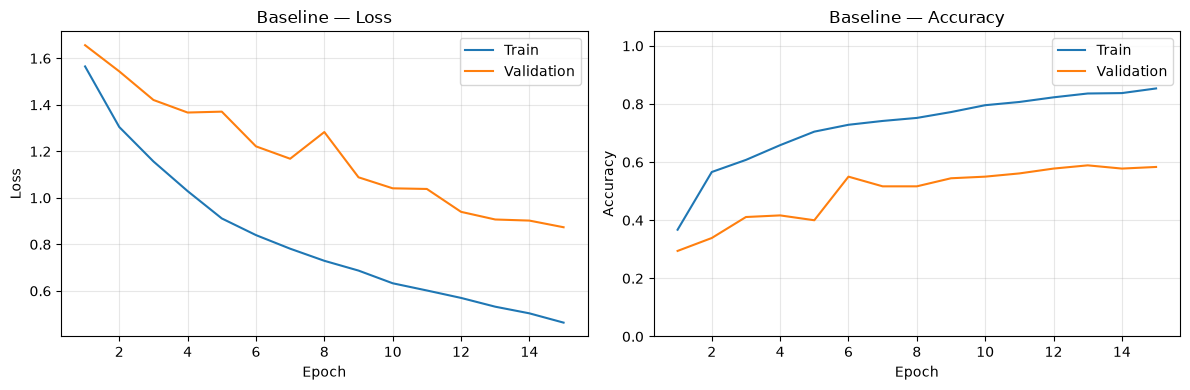

In [7]:
model = run_experiment(
    name="Baseline",
    channels=[8],
)
del model
cleanup_device()

## 6. 실험 1 — Conv Layer 1개 추가

특징 추출 능력을 높이기 위해 전체 Conv Layer를 2개로 구성한다.


E1 Conv2
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7056, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=6, bias=True)
  )
)
parameters: 229,446


Epoch 001 | train 1.611, 0.314 | val 1.786, 0.272 | lr 1.0e-03


Epoch 002 | train 1.372, 0.493 | val 1.629, 0.400 | lr 1.0e-03


Epoch 003 | train 1.172, 0.609 | val 1.738, 0.333 | lr 1.0e-03


Epoch 004 | train 1.103, 0.615 | val 1.628, 0.450 | lr 1.0e-03


...

Epoch 011 | train 0.484, 0.847 | val 0.982, 0.544 | lr 1.0e-03


Epoch 012 | train 0.452, 0.854 | val 0.972, 0.678 | lr 1.0e-03


Epoch 013 | train 0.444, 0.853 | val 0.875, 0.722 | lr 1.0e-03


Epoch 014 | train 0.447, 0.852 | val 0.794, 0.672 | lr 1.0e-03


Epoch 015 | train 0.422, 0.854 | val 0.840, 0.700 | lr 1.0e-03
Best epoch: 14
Validation Loss: 0.794
Validation Accuracy: 0.672
Validation Macro F1: 0.672


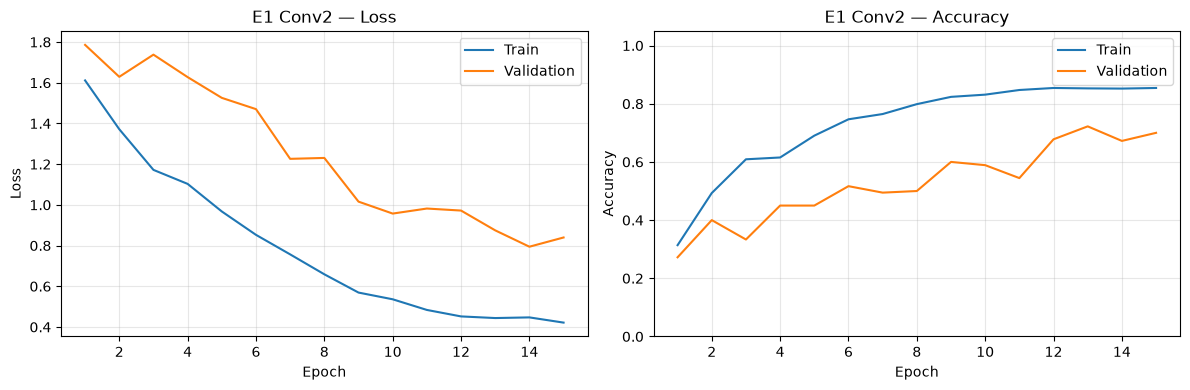

In [8]:
model = run_experiment(
    name="E1 Conv2",
    channels=[8, 16],
)
del model
cleanup_device()

## 7. 실험 2 — Conv Layer 2개 추가

더 깊은 특징을 추출하고 Pooling을 통해 완전연결층의 파라미터를 줄인다.


E2 Conv3
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=6, bias=True)
  )
)
parameters: 82,022


Epoch 001 | train 1.704, 0.221 | val 1.749, 0.267 | lr 1.0e-03


Epoch 002 | train 1.554, 0.351 | val 1.624, 0.317 | lr 1.0e-03


Epoch 003 | train 1.495, 0.350 | val 1.598, 0.333 | lr 1.0e-03


Epoch 004 | train 1.336, 0.507 | val 1.549, 0.394 | lr 1.0e-03


...

Epoch 011 | train 0.615, 0.795 | val 0.943, 0.583 | lr 1.0e-03


Epoch 012 | train 0.573, 0.812 | val 1.077, 0.606 | lr 1.0e-03


Epoch 013 | train 0.562, 0.810 | val 0.896, 0.639 | lr 1.0e-03


Epoch 014 | train 0.575, 0.809 | val 0.987, 0.583 | lr 1.0e-03


Epoch 015 | train 0.538, 0.811 | val 0.759, 0.672 | lr 1.0e-03
Best epoch: 15
Validation Loss: 0.759
Validation Accuracy: 0.672
Validation Macro F1: 0.669


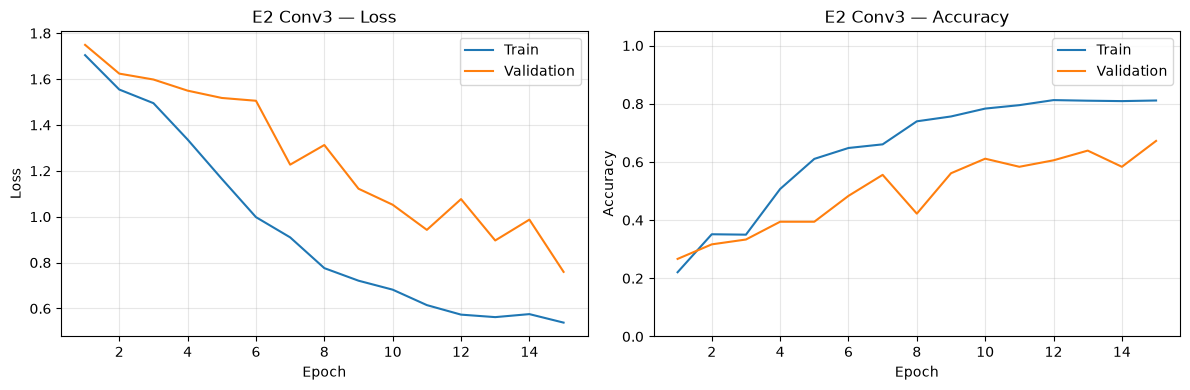

In [9]:
model = run_experiment(
    name="E2 Conv3",
    channels=[8, 16, 32],
)
del model
cleanup_device()

## 8. 실험 3 — Conv Layer 3개 추가

전체 Conv Layer를 4개로 늘려 깊이 증가의 효과와 공간 정보 손실을 확인한다.


E3 Conv4
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=6, bias=True)
  )
)
parameters: 75,942


Epoch 001 | train 1.764, 0.212 | val 1.710, 0.294 | lr 1.0e-03


Epoch 002 | train 1.526, 0.368 | val 1.788, 0.228 | lr 1.0e-03


Epoch 003 | train 1.378, 0.506 | val 1.654, 0.378 | lr 1.0e-03


Epoch 004 | train 1.229, 0.522 | val 1.422, 0.450 | lr 1.0e-03


...

Epoch 011 | train 0.757, 0.734 | val 1.031, 0.556 | lr 1.0e-03


Epoch 012 | train 0.758, 0.724 | val 1.105, 0.561 | lr 1.0e-03


Epoch 013 | train 0.710, 0.756 | val 0.910, 0.589 | lr 1.0e-03


Epoch 014 | train 0.702, 0.746 | val 0.936, 0.611 | lr 1.0e-03


Epoch 015 | train 0.584, 0.803 | val 0.872, 0.633 | lr 1.0e-03
Best epoch: 15
Validation Loss: 0.872
Validation Accuracy: 0.633
Validation Macro F1: 0.626


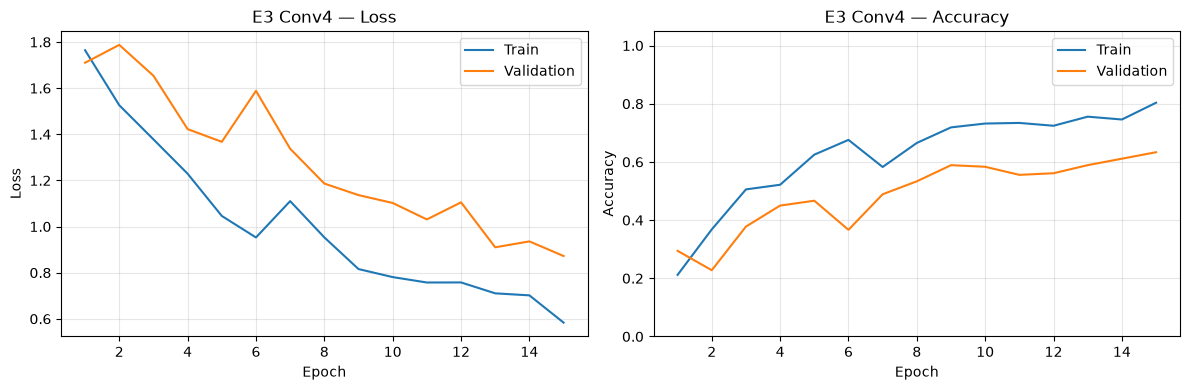

In [10]:
model = run_experiment(
    name="E3 Conv4",
    channels=[8, 16, 32, 64],
)
del model
cleanup_device()

## 9. 실험 4 — Dropout

Conv 3개 구조의 완전연결층에 Dropout 0.5를 적용해 과적합을 완화한다.


E4 Dropout
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=32, out_features=6, bias=True)
  )
)
parameters: 82,022


Epoch 001 | train 1.731, 0.220 | val 1.670, 0.272 | lr 1.0e-03


Epoch 002 | train 1.614, 0.305 | val 1.632, 0.283 | lr 1.0e-03


Epoch 003 | train 1.558, 0.358 | val 1.536, 0.389 | lr 1.0e-03


Epoch 004 | train 1.442, 0.418 | val 1.494, 0.417 | lr 1.0e-03


...

Epoch 011 | train 0.940, 0.642 | val 1.083, 0.522 | lr 1.0e-03


Epoch 012 | train 0.939, 0.659 | val 1.090, 0.456 | lr 1.0e-03


Epoch 013 | train 0.930, 0.626 | val 1.027, 0.583 | lr 1.0e-03


Epoch 014 | train 0.974, 0.626 | val 1.140, 0.517 | lr 1.0e-03


Epoch 015 | train 0.887, 0.677 | val 1.029, 0.589 | lr 1.0e-03
Best epoch: 13
Validation Loss: 1.027
Validation Accuracy: 0.583
Validation Macro F1: 0.555


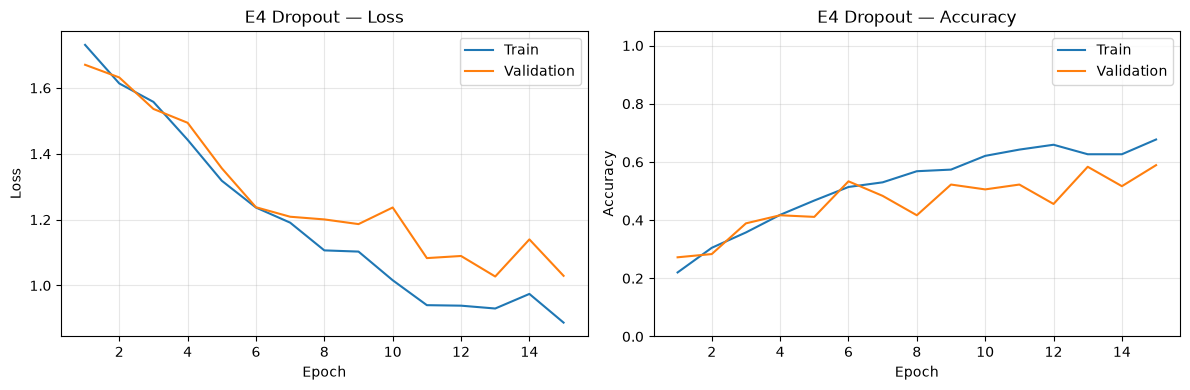

In [11]:
model = run_experiment(
    name="E4 Dropout",
    channels=[8, 16, 32],
    classifier_dropout=0.5,
)
del model
cleanup_device()

## 10. 실험 5 — Batch Normalization

Conv 3개 구조의 Conv 및 FC 층에 Batch Normalization을 적용해 학습을 안정화한다.


E5 BatchNorm
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=1e-05

Epoch 001 | train 1.158, 0.648 | val 2.009, 0.211 | lr 1.0e-03


Epoch 002 | train 0.826, 0.813 | val 1.745, 0.272 | lr 1.0e-03


Epoch 003 | train 0.658, 0.873 | val 1.172, 0.478 | lr 1.0e-03


Epoch 004 | train 0.481, 0.910 | val 1.046, 0.550 | lr 1.0e-03


...

Epoch 011 | train 0.157, 0.969 | val 1.101, 0.683 | lr 1.0e-03


Epoch 012 | train 0.149, 0.966 | val 0.347, 0.894 | lr 1.0e-03


Epoch 013 | train 0.132, 0.972 | val 0.260, 0.911 | lr 1.0e-03


Epoch 014 | train 0.122, 0.971 | val 0.241, 0.933 | lr 1.0e-03


Epoch 015 | train 0.095, 0.982 | val 0.229, 0.933 | lr 1.0e-03
Best epoch: 15
Validation Loss: 0.229
Validation Accuracy: 0.933
Validation Macro F1: 0.932


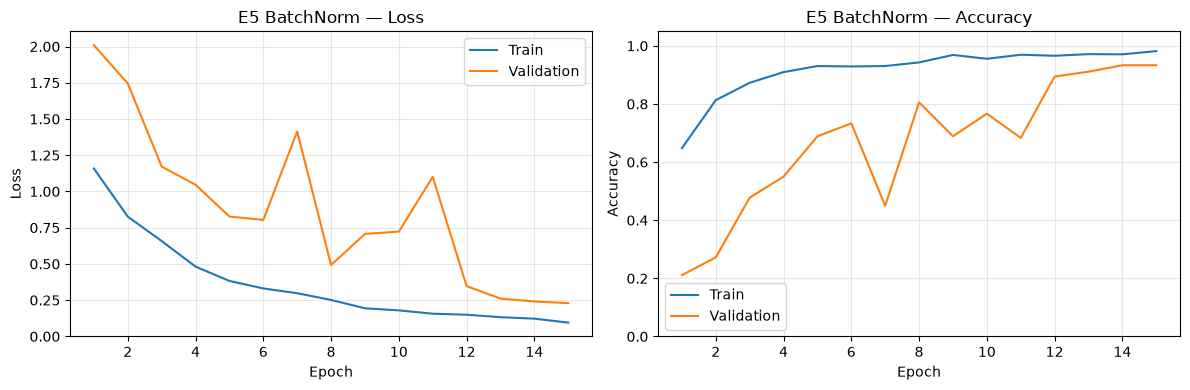

In [12]:
model = run_experiment(
    name="E5 BatchNorm",
    channels=[8, 16, 32],
    batch_norm=True,
)
del model
cleanup_device()

## 11. 실험 6 — 기본 데이터 증강

Batch Normalization 구조를 유지하고 Train 데이터에 좌우·상하 반전을 적용한다.


E6 Flip Augmentation
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): BatchNorm1d(32, e

Epoch 001 | train 1.146, 0.646 | val 2.057, 0.206 | lr 1.0e-03


Epoch 002 | train 0.817, 0.824 | val 1.961, 0.267 | lr 1.0e-03


Epoch 003 | train 0.660, 0.865 | val 1.630, 0.400 | lr 1.0e-03


Epoch 004 | train 0.553, 0.873 | val 1.004, 0.656 | lr 1.0e-03


...

Epoch 011 | train 0.183, 0.956 | val 0.314, 0.933 | lr 1.0e-03


Epoch 012 | train 0.148, 0.967 | val 0.389, 0.878 | lr 1.0e-03


Epoch 013 | train 0.187, 0.947 | val 0.497, 0.800 | lr 1.0e-03


Epoch 014 | train 0.150, 0.963 | val 0.576, 0.867 | lr 1.0e-03


Epoch 015 | train 0.151, 0.963 | val 0.679, 0.706 | lr 1.0e-03
Best epoch: 11
Validation Loss: 0.314
Validation Accuracy: 0.933
Validation Macro F1: 0.930


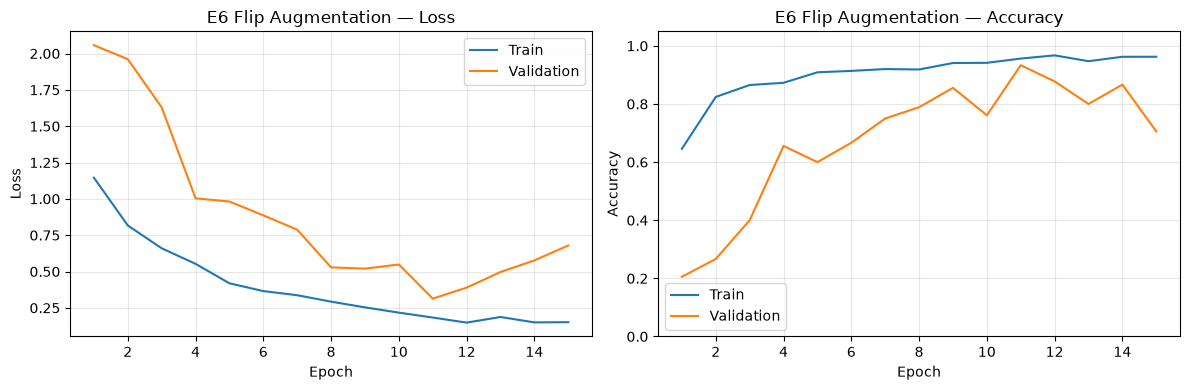

In [13]:
model = run_experiment(
    name="E6 Flip Augmentation",
    channels=[8, 16, 32],
    batch_norm=True,
    train_transform=flip_transform,
)
del model
cleanup_device()

## 12. 실험 7 — Learning Rate 조정

증강을 제외한 Batch Normalization 구조에서 Learning Rate를 3e-4로 낮춘다.


E7 LR 3e-4
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=1e-05, 

Epoch 001 | train 1.268, 0.603 | val 2.118, 0.172 | lr 3.0e-04


Epoch 002 | train 0.997, 0.742 | val 1.718, 0.256 | lr 3.0e-04


Epoch 003 | train 0.884, 0.826 | val 1.521, 0.350 | lr 3.0e-04


Epoch 004 | train 0.774, 0.866 | val 1.123, 0.639 | lr 3.0e-04


...

Epoch 011 | train 0.384, 0.942 | val 0.506, 0.878 | lr 3.0e-04


Epoch 012 | train 0.330, 0.958 | val 0.548, 0.872 | lr 3.0e-04


Epoch 013 | train 0.329, 0.954 | val 0.490, 0.889 | lr 3.0e-04


Epoch 014 | train 0.315, 0.956 | val 0.544, 0.894 | lr 3.0e-04


Epoch 015 | train 0.277, 0.962 | val 0.442, 0.933 | lr 3.0e-04
Best epoch: 15
Validation Loss: 0.442
Validation Accuracy: 0.933
Validation Macro F1: 0.932


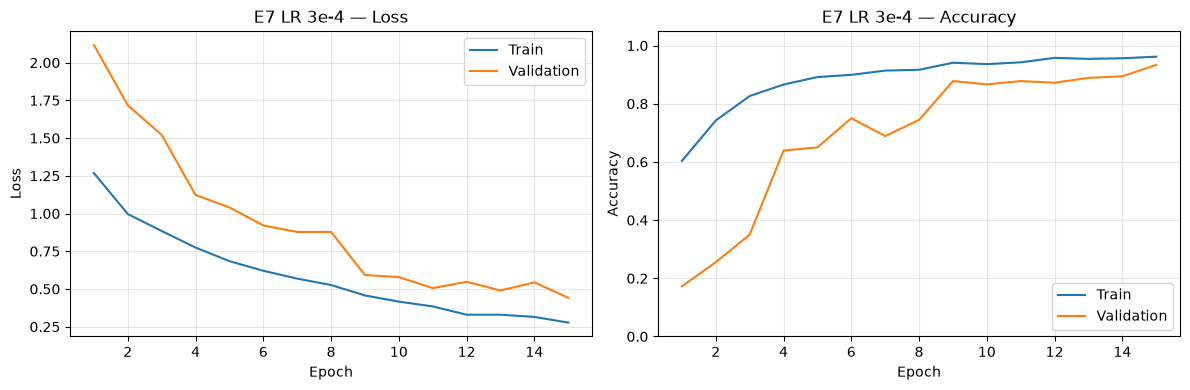

In [14]:
model = run_experiment(
    name="E7 LR 3e-4",
    channels=[8, 16, 32],
    batch_norm=True,
    learning_rate=3e-4,
)
del model
cleanup_device()

## 13. 실험 8 — Epoch 증가 및 Early Stopping

작은 Learning Rate에서 충분히 수렴하도록 최대 200 Epoch와 Early Stopping을 적용한다.


E8 Early Stopping
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=

Epoch 001 | train 1.268, 0.603 | val 2.118, 0.172 | lr 3.0e-04 | patience 0/6


Epoch 002 | train 0.997, 0.742 | val 1.718, 0.256 | lr 3.0e-04 | patience 0/6


Epoch 003 | train 0.884, 0.826 | val 1.521, 0.350 | lr 3.0e-04 | patience 0/6


Epoch 004 | train 0.774, 0.866 | val 1.123, 0.639 | lr 3.0e-04 | patience 0/6


...

Epoch 033 | train 0.070, 0.994 | val 0.387, 0.900 | lr 3.0e-04 | patience 2/6


Epoch 034 | train 0.085, 0.988 | val 0.335, 0.894 | lr 3.0e-04 | patience 3/6


Epoch 035 | train 0.080, 0.992 | val 0.474, 0.850 | lr 3.0e-04 | patience 4/6


Epoch 036 | train 0.068, 0.994 | val 0.285, 0.922 | lr 3.0e-04 | patience 5/6


Epoch 037 | train 0.059, 0.997 | val 0.426, 0.900 | lr 3.0e-04 | patience 6/6
Early stopping at epoch 37
Best epoch: 31
Validation Loss: 0.251
Validation Accuracy: 0.933
Validation Macro F1: 0.932


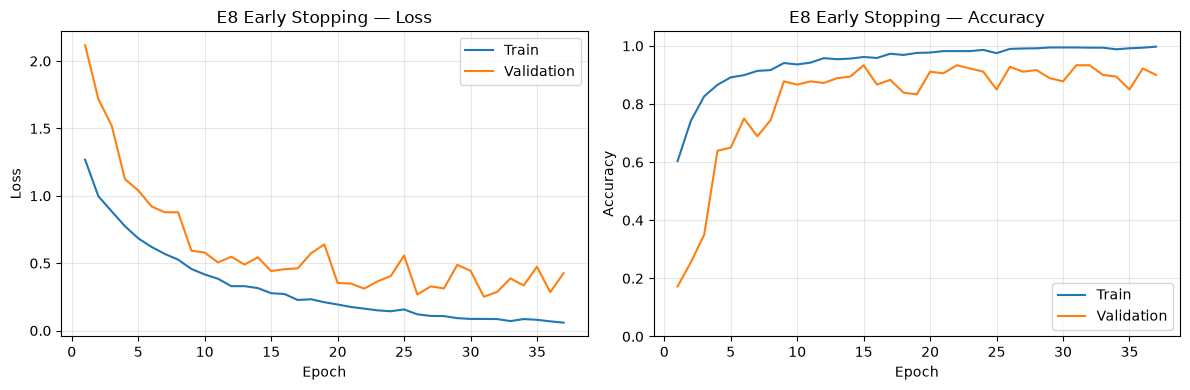

In [15]:
model = run_experiment(
    name="E8 Early Stopping",
    channels=[8, 16, 32],
    batch_norm=True,
    learning_rate=3e-4,
    epochs=200,
    early_stopping_patience=6,
)
del model
cleanup_device()

## 14. 실험 9 — Learning Rate Scheduler

Validation Loss 정체 시 Learning Rate를 절반으로 낮추는 Scheduler를 추가한다.


E9 Scheduler
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=1e-05

Epoch 001 | train 1.268, 0.603 | val 2.118, 0.172 | lr 3.0e-04 | patience 0/6


Epoch 002 | train 0.997, 0.742 | val 1.718, 0.256 | lr 3.0e-04 | patience 0/6


Epoch 003 | train 0.884, 0.826 | val 1.521, 0.350 | lr 3.0e-04 | patience 0/6


Epoch 004 | train 0.774, 0.866 | val 1.123, 0.639 | lr 3.0e-04 | patience 0/6


...

Epoch 033 | train 0.070, 0.994 | val 0.387, 0.900 | lr 3.0e-04 | patience 2/6


Epoch 034 | train 0.085, 0.988 | val 0.335, 0.894 | lr 3.0e-04 | patience 3/6


Epoch 035 | train 0.080, 0.992 | val 0.474, 0.850 | lr 3.0e-04 | patience 4/6


Epoch 036 | train 0.068, 0.994 | val 0.285, 0.922 | lr 1.5e-04 | patience 5/6


Epoch 037 | train 0.055, 0.997 | val 0.339, 0.911 | lr 1.5e-04 | patience 6/6
Early stopping at epoch 37
Best epoch: 31
Validation Loss: 0.251
Validation Accuracy: 0.933
Validation Macro F1: 0.932


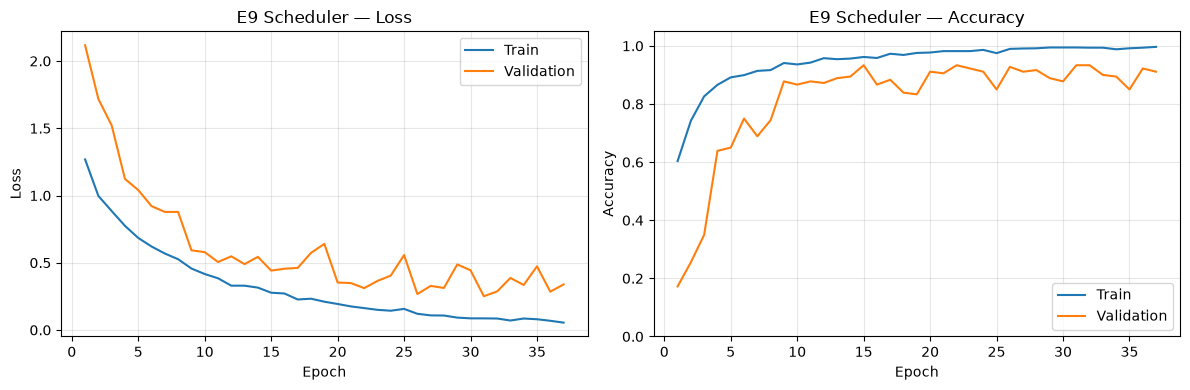

In [16]:
model = run_experiment(
    name="E9 Scheduler",
    channels=[8, 16, 32],
    batch_norm=True,
    learning_rate=3e-4,
    epochs=200,
    early_stopping_patience=6,
    scheduler_patience=4,
)
del model
cleanup_device()

## 15. 실험 10 — 데이터 증강 보완

좌우·상하 반전에 ±10도 회전을 추가하고 Scheduler의 반응 속도를 높인다.


E10 Full Augmentation
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=32, bias=True)
    (2): BatchNorm1d(32, 

Epoch 001 | train 1.271, 0.630 | val 2.144, 0.194 | lr 3.0e-04 | patience 0/6


Epoch 002 | train 1.030, 0.744 | val 1.778, 0.228 | lr 3.0e-04 | patience 0/6


Epoch 003 | train 0.923, 0.809 | val 1.462, 0.372 | lr 3.0e-04 | patience 0/6


Epoch 004 | train 0.830, 0.832 | val 1.078, 0.711 | lr 3.0e-04 | patience 0/6


...

Epoch 033 | train 0.160, 0.974 | val 0.520, 0.794 | lr 7.5e-05 | patience 2/6


Epoch 034 | train 0.167, 0.972 | val 0.524, 0.789 | lr 3.7e-05 | patience 3/6


Epoch 035 | train 0.158, 0.974 | val 0.466, 0.811 | lr 3.7e-05 | patience 4/6


Epoch 036 | train 0.147, 0.981 | val 0.361, 0.850 | lr 3.7e-05 | patience 5/6


Epoch 037 | train 0.149, 0.981 | val 0.368, 0.844 | lr 1.9e-05 | patience 6/6
Early stopping at epoch 37
Best epoch: 31
Validation Loss: 0.345
Validation Accuracy: 0.856
Validation Macro F1: 0.857


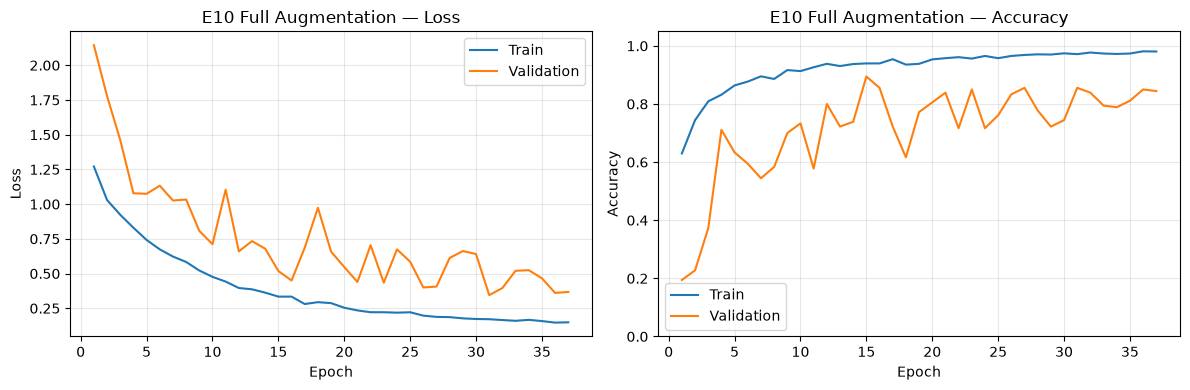

In [17]:
model = run_experiment(
    name="E10 Full Augmentation",
    channels=[8, 16, 32],
    batch_norm=True,
    train_transform=full_augmentation_transform,
    learning_rate=3e-4,
    epochs=200,
    early_stopping_patience=6,
    scheduler_patience=2,
)
del model
cleanup_device()

## 16. 실험 11 — 최종 Conv Layer 추가

증강된 이미지의 복잡한 특징을 추출하기 위해 Conv 4개 구조로 확장한다.


E11 Conv4 + Augmentation
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=Tru

Epoch 001 | train 1.376, 0.600 | val 1.848, 0.178 | lr 3.0e-04 | patience 0/6


Epoch 002 | train 1.070, 0.755 | val 1.773, 0.267 | lr 3.0e-04 | patience 0/6


Epoch 003 | train 0.940, 0.816 | val 1.508, 0.411 | lr 3.0e-04 | patience 0/6


Epoch 004 | train 0.826, 0.860 | val 1.069, 0.672 | lr 3.0e-04 | patience 0/6


...

Epoch 027 | train 0.179, 0.976 | val 0.556, 0.800 | lr 7.5e-05 | patience 2/6


Epoch 028 | train 0.180, 0.974 | val 0.494, 0.844 | lr 3.7e-05 | patience 3/6


Epoch 029 | train 0.173, 0.972 | val 0.428, 0.850 | lr 3.7e-05 | patience 4/6


Epoch 030 | train 0.171, 0.976 | val 0.589, 0.794 | lr 3.7e-05 | patience 5/6


Epoch 031 | train 0.178, 0.970 | val 0.364, 0.894 | lr 1.9e-05 | patience 6/6
Early stopping at epoch 31
Best epoch: 25
Validation Loss: 0.339
Validation Accuracy: 0.911
Validation Macro F1: 0.910


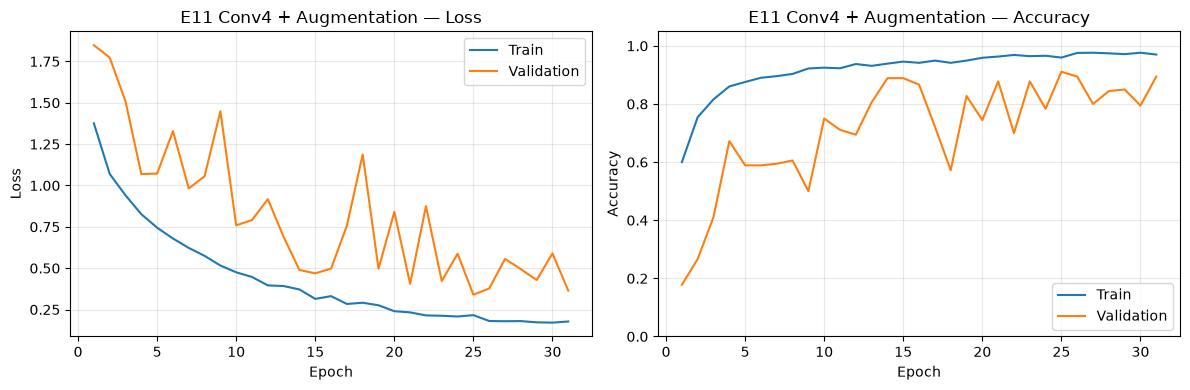

In [18]:
model = run_experiment(
    name="E11 Conv4 + Augmentation",
    channels=[8, 16, 32, 64],
    batch_norm=True,
    train_transform=full_augmentation_transform,
    learning_rate=3e-4,
    epochs=200,
    early_stopping_patience=6,
    scheduler_patience=2,
)
del model
cleanup_device()

## 17. 실험 12 — 최종 Dropout 모델

Conv 4개 구조에 특징부 Dropout 0.25와 분류부 Dropout 0.5를 적용한다. 증강은 제외하며 Test 평가는 이 실험에서만 수행한다.


E12 Final Dropout
ExperimentCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    

Epoch 001 | train 1.555, 0.389 | val 1.839, 0.172 | lr 3.0e-04 | patience 0/6


Epoch 002 | train 1.259, 0.607 | val 1.813, 0.233 | lr 3.0e-04 | patience 0/6


Epoch 003 | train 1.127, 0.693 | val 1.650, 0.356 | lr 3.0e-04 | patience 0/6


Epoch 004 | train 1.009, 0.751 | val 1.286, 0.539 | lr 3.0e-04 | patience 0/6


...

Epoch 036 | train 0.240, 0.957 | val 0.268, 0.922 | lr 1.5e-04 | patience 2/6


Epoch 037 | train 0.249, 0.957 | val 0.335, 0.906 | lr 1.5e-04 | patience 3/6


Epoch 038 | train 0.261, 0.958 | val 0.227, 0.950 | lr 1.5e-04 | patience 4/6


Epoch 039 | train 0.235, 0.965 | val 0.246, 0.944 | lr 7.5e-05 | patience 5/6


Epoch 040 | train 0.262, 0.950 | val 0.264, 0.911 | lr 7.5e-05 | patience 6/6
Early stopping at epoch 40
Best epoch: 34
Validation Loss: 0.217
Validation Accuracy: 0.928
Validation Macro F1: 0.926


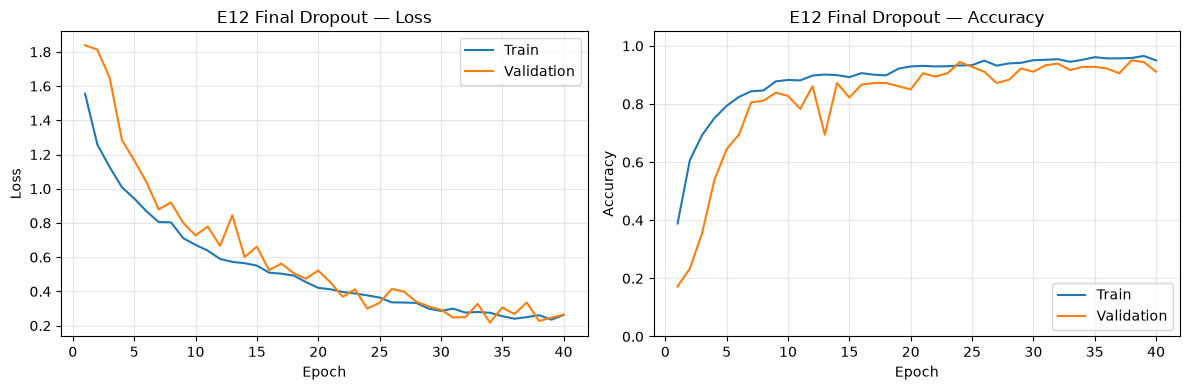

Test Accuracy: 0.989
Test Macro F1: 0.989


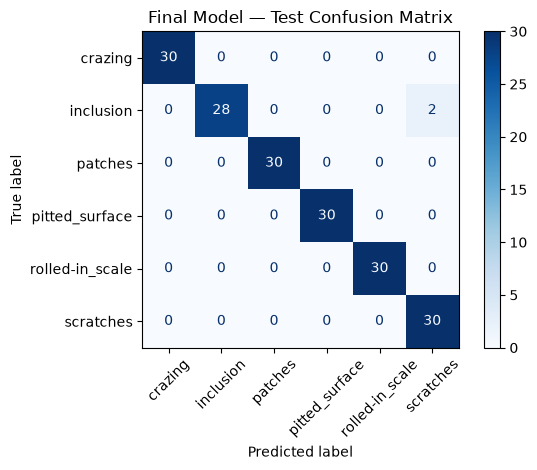

In [19]:
final_model = run_experiment(
    name="E12 Final Dropout",
    channels=[8, 16, 32, 64],
    batch_norm=True,
    feature_dropout=0.25,
    classifier_dropout=0.5,
    train_transform=base_transform,
    learning_rate=3e-4,
    epochs=200,
    early_stopping_patience=6,
    scheduler_patience=4,
    evaluate_test=True,
)

## 18. 전체 실험 결과 비교

In [20]:
headers = [
    "Experiment", "Parameters", "Best", "Stop",
    "Val Loss", "Val Acc", "Macro F1", "Test Acc", "Test F1"
]

lines = [
    "| " + " | ".join(headers) + " |",
    "|" + "|".join(["---"] * len(headers)) + "|",
]

for result in experiment_results:
    test_acc = (
        "-" if result["test_accuracy"] is None
        else f'{result["test_accuracy"]:.3f}'
    )
    test_f1 = (
        "-" if result["test_macro_f1"] is None
        else f'{result["test_macro_f1"]:.3f}'
    )
    lines.append(
        "| " + " | ".join([
            result["experiment"],
            f'{result["parameters"]:,}',
            str(result["best_epoch"]),
            str(result["stop_epoch"]),
            f'{result["val_loss"]:.3f}',
            f'{result["val_accuracy"]:.3f}',
            f'{result["val_macro_f1"]:.3f}',
            test_acc,
            test_f1,
        ]) + " |"
    )

display(Markdown("\n".join(lines)))

| Experiment | Parameters | Best | Stop | Val Loss | Val Acc | Macro F1 | Test Acc | Test F1 |
|---|---|---|---|---|---|---|---|---|
| Baseline | 542,134 | 15 | 15 | 0.874 | 0.583 | 0.559 | - | - |
| E1 Conv2 | 229,446 | 14 | 15 | 0.794 | 0.672 | 0.672 | - | - |
| E2 Conv3 | 82,022 | 15 | 15 | 0.759 | 0.672 | 0.669 | - | - |
| E3 Conv4 | 75,942 | 15 | 15 | 0.872 | 0.633 | 0.626 | - | - |
| E4 Dropout | 82,022 | 13 | 15 | 1.027 | 0.583 | 0.555 | - | - |
| E5 BatchNorm | 82,198 | 15 | 15 | 0.229 | 0.933 | 0.932 | - | - |
| E6 Flip Augmentation | 82,198 | 11 | 15 | 0.314 | 0.933 | 0.930 | - | - |
| E7 LR 3e-4 | 82,198 | 15 | 15 | 0.442 | 0.933 | 0.932 | - | - |
| E8 Early Stopping | 82,198 | 31 | 37 | 0.251 | 0.933 | 0.932 | - | - |
| E9 Scheduler | 82,198 | 31 | 37 | 0.251 | 0.933 | 0.932 | - | - |
| E10 Full Augmentation | 82,198 | 31 | 37 | 0.345 | 0.856 | 0.857 | - | - |
| E11 Conv4 + Augmentation | 76,246 | 25 | 31 | 0.339 | 0.911 | 0.910 | - | - |
| E12 Final Dropout | 76,246 | 34 | 40 | 0.217 | 0.928 | 0.926 | 0.989 | 0.989 |

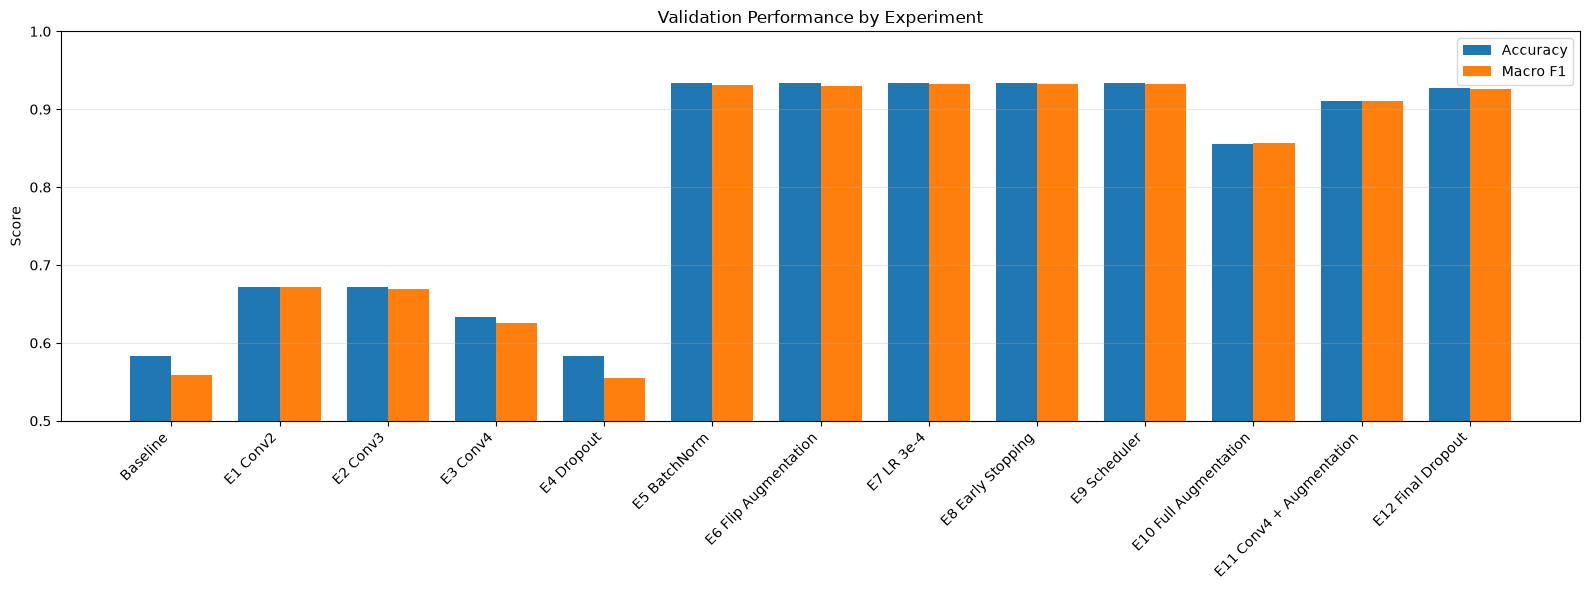

In [21]:
names = [result["experiment"] for result in experiment_results]
accuracies = [result["val_accuracy"] for result in experiment_results]
macro_f1 = [result["val_macro_f1"] for result in experiment_results]

x = np.arange(len(names))
width = 0.38

plt.figure(figsize=(16, 6))
plt.bar(x - width / 2, accuracies, width, label="Accuracy")
plt.bar(x + width / 2, macro_f1, width, label="Macro F1")
plt.xticks(x, names, rotation=45, ha="right")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.title("Validation Performance by Experiment")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 19. 최종 결론

전체 실험은 동일하게 고정된 초기 데이터에서 각각 독립적으로 실행된다. 각 단계에서는 한정된 변경 요소가 모델 성능에 미치는 영향을 확인하고, 그 결과를 바탕으로 다음 실험을 설계하였다.

최종 모델은 Conv 4개 구조에 Batch Normalization과 두 단계의 Dropout을 적용하고, Scheduler와 Early Stopping으로 학습을 제어한다. Test 데이터는 이 최종 모델에서만 사용한다.

> 참고: 실험 12에서는 Dropout 추가와 함께 데이터 증강 제거 및 Scheduler patience 변경이 이루어지므로, 향후에는 나머지 조건을 고정한 Ablation Study로 각 요소의 독립적인 효과를 검증할 필요가 있다.